In [1]:
from sklearn.tree import ExtraTreeClassifier
from scipy.stats import randint, uniform
import sys
from pathlib import Path

# Go up one level to project root
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

from src.utils.tune_hyperparameters import ModelTuner, PipelineTuner
filename = r"../../data/raw/ACME-HappinessSurvey2020.csv"

from sklearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import ExtraTreeClassifier
from sklearn.compose import ColumnTransformer

e:\dev\workspace\Apziva\Project1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


___
# Tuning just the model - all features
___

In [2]:
random_state = 0

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START criterion=gini, max_depth=2, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, splitter=best
[CV 1/5; 1/100] END criterion=gini, max_depth=2, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, splitter=best;, score=(train=0.700, test=0.450) total time=   0.0s
[CV 2/5; 1/100] START criterion=gini, max_depth=2, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, splitter=best
[CV 2/5; 1/100] END criterion=gini, max_depth=2, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, splitter=best;, score=(train=0.637, test=0.850) total time=   0.0s
[CV 3/5; 1/100] START criterion=gini, max_depth=2, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, splitter=best
[CV 3/5; 1/100] END criterion=gini, max_depth=2, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, splitter=best;, score=(train=0.725, test=0.500) total time=   0.0s
[CV 4/5; 1/100] START criterion=gi

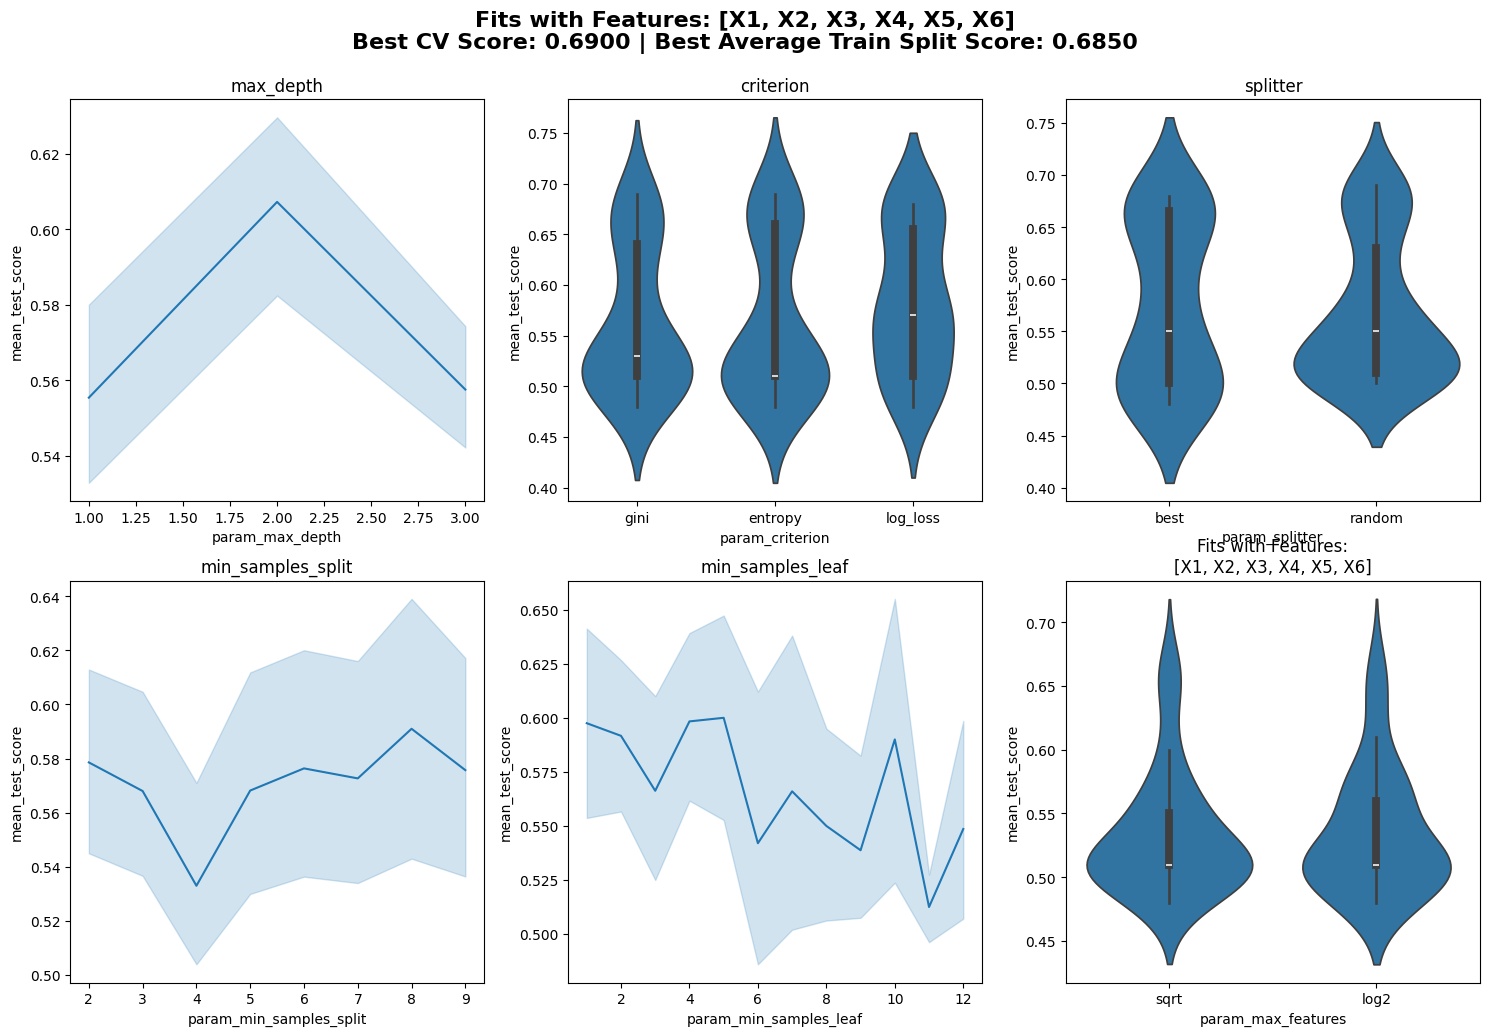



Feature Permutation Importance
______________________
X1: 0.050 +/- 0.077
X3: 0.046 +/- 0.059
X5: 0.000 +/- 0.000
X6: 0.000 +/- 0.000
X4: 0.000 +/- 0.000
X2: 0.000 +/- 0.000

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


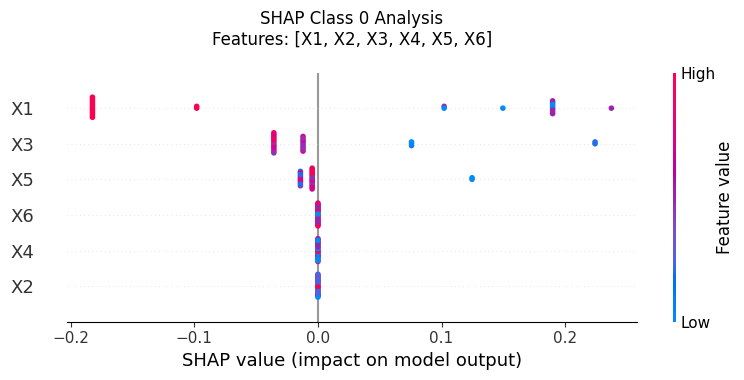

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


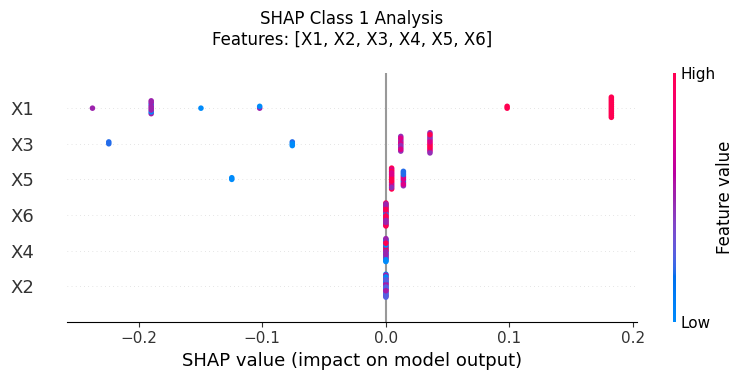

In [3]:
categorical_features = ["X1","X2","X3","X4","X5","X6"]

model = ExtraTreeClassifier(random_state = random_state,)

t0 = ModelTuner(model, filename, "Y", categorical_features, random_state=random_state)

parameter_grid = {
                    'max_depth':randint(1,4), # trying to avoid overfitting
                    'criterion':("gini", "entropy", "log_loss"),
                    'splitter': ("random", "best"),
                    'min_samples_split':randint(2,10),
                    'min_samples_leaf':randint(1,13),
                    'max_features': ("sqrt", "log2", None),
            }
search = t0.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100)
t0.feature_permutation(search.best_params_)
t0.shap_analysis(search.best_params_)

seemd to ignore features 2,4,6 which fits with EDA

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START criterion=gini, max_depth=2, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, splitter=best
[CV 1/5; 1/100] END criterion=gini, max_depth=2, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, splitter=best;, score=(train=0.688, test=0.550) total time=   0.0s
[CV 2/5; 1/100] START criterion=gini, max_depth=2, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, splitter=best
[CV 2/5; 1/100] END criterion=gini, max_depth=2, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, splitter=best;, score=(train=0.637, test=0.750) total time=   0.0s
[CV 3/5; 1/100] START criterion=gini, max_depth=2, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, splitter=best
[CV 3/5; 1/100] END criterion=gini, max_depth=2, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, splitter=best;, score=(train=0.688, test=0.350) total time=   0.0s
[CV 4/5; 1/100] START criterion=gi

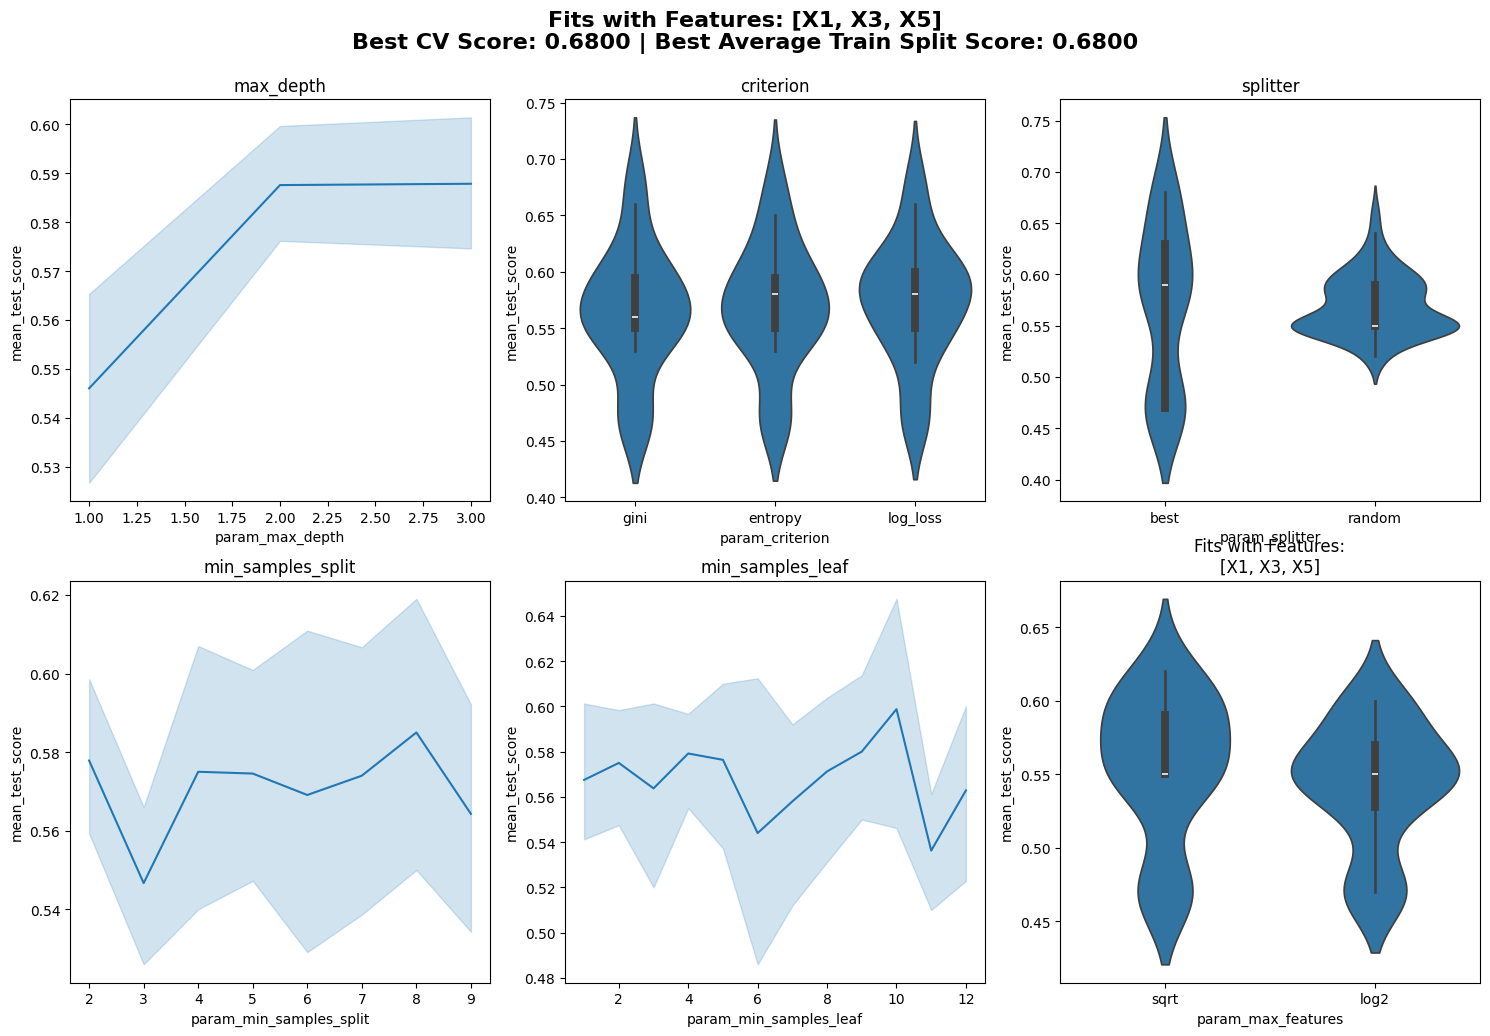



Feature Permutation Importance
______________________
X1: 0.062 +/- 0.108
X5: 0.000 +/- 0.000
X3: 0.000 +/- 0.000

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


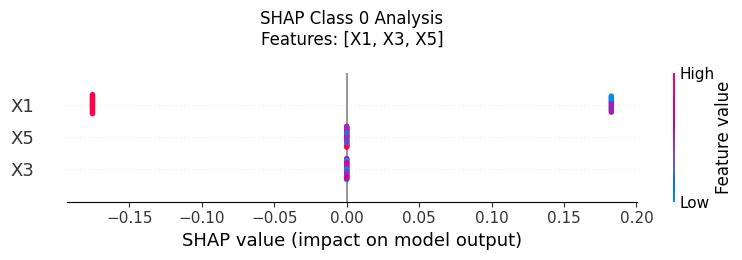

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


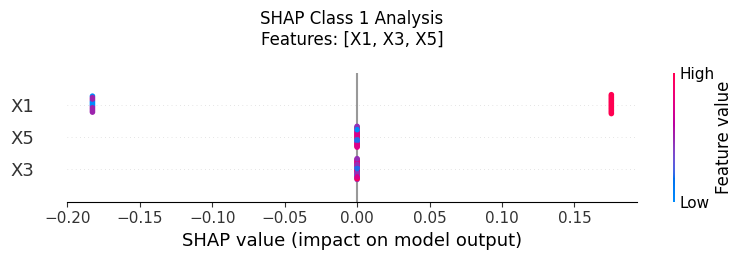

In [4]:
categorical_features = ["X1","X3","X5"]
t0.set_features(categorical_features)
parameter_grid = {
                    'max_depth':randint(1,4), # trying to avoid overfitting
                    'criterion':("gini", "entropy", "log_loss"),
                    'splitter': ("random", "best"),
                    'min_samples_split':randint(2,10),
                    'min_samples_leaf':randint(1,13),
                    'max_features': ("sqrt", "log2", None),
            }
search = t0.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100)
t0.feature_permutation(search.best_params_)
t0.shap_analysis(search.best_params_)

seems to have fit to a single variable. maybe more aggressive regularization

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START criterion=gini, max_depth=2, max_features=log2, min_samples_leaf=6, min_samples_split=9, splitter=best
[CV 1/5; 1/100] END criterion=gini, max_depth=2, max_features=log2, min_samples_leaf=6, min_samples_split=9, splitter=best;, score=(train=0.688, test=0.550) total time=   0.0s
[CV 2/5; 1/100] START criterion=gini, max_depth=2, max_features=log2, min_samples_leaf=6, min_samples_split=9, splitter=best
[CV 2/5; 1/100] END criterion=gini, max_depth=2, max_features=log2, min_samples_leaf=6, min_samples_split=9, splitter=best;, score=(train=0.637, test=0.750) total time=   0.0s
[CV 3/5; 1/100] START criterion=gini, max_depth=2, max_features=log2, min_samples_leaf=6, min_samples_split=9, splitter=best
[CV 3/5; 1/100] END criterion=gini, max_depth=2, max_features=log2, min_samples_leaf=6, min_samples_split=9, splitter=best;, score=(train=0.688, test=0.350) total time=   0.0s
[CV 4/5; 1/100] START criterion=gi

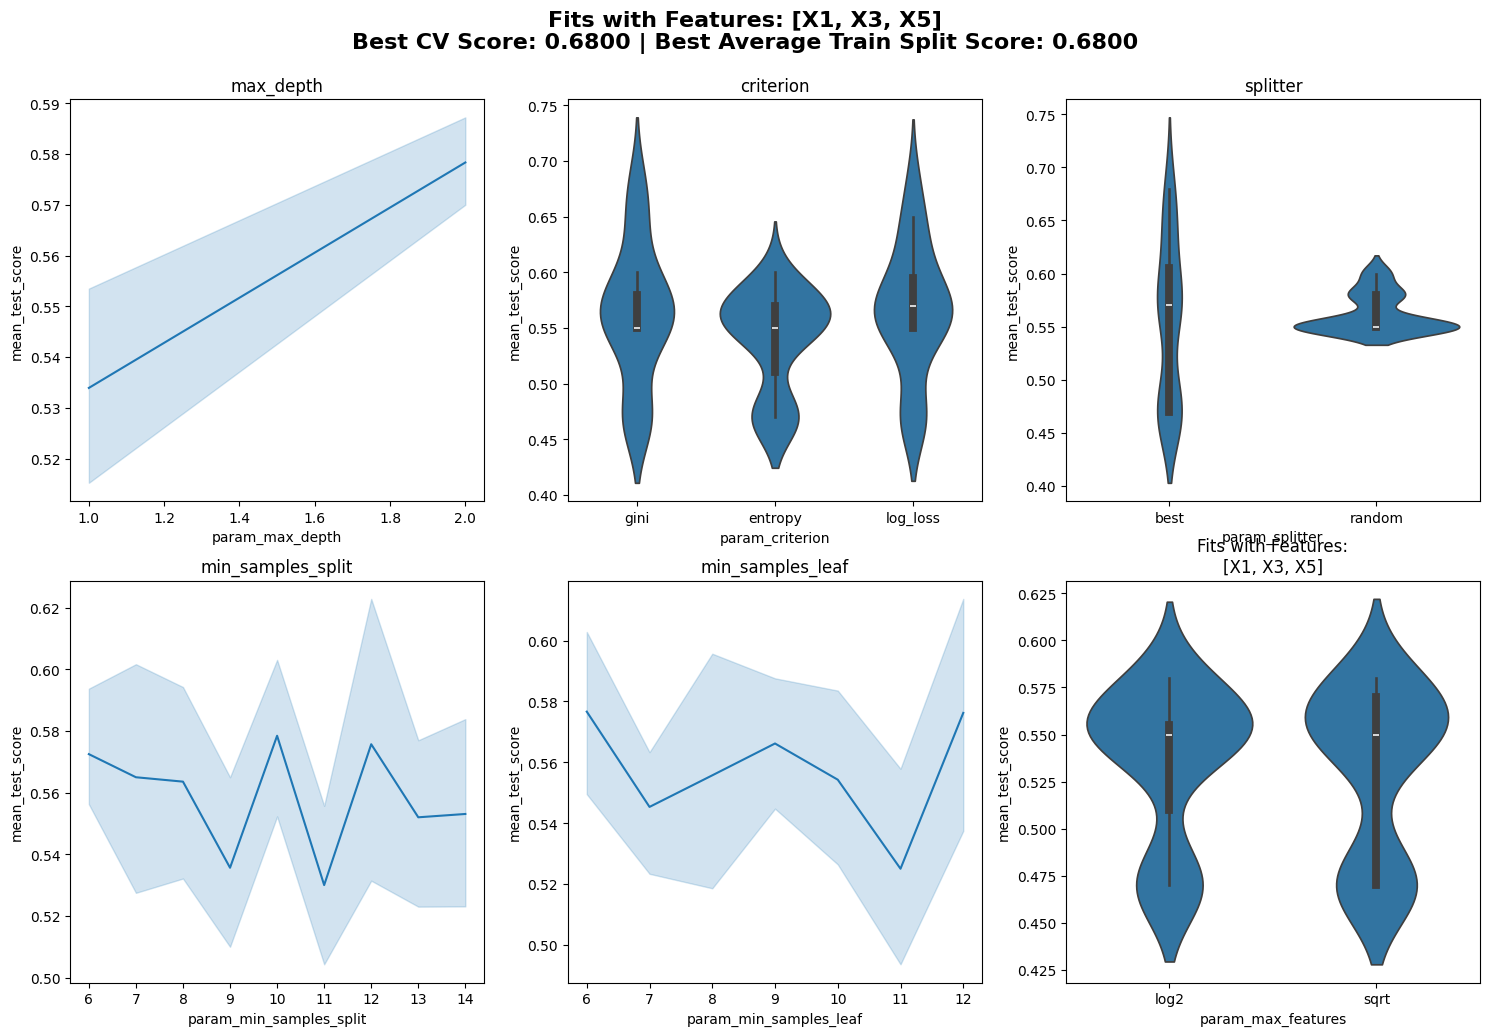



Feature Permutation Importance
______________________
X1: 0.062 +/- 0.108
X5: 0.000 +/- 0.000
X3: 0.000 +/- 0.000

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


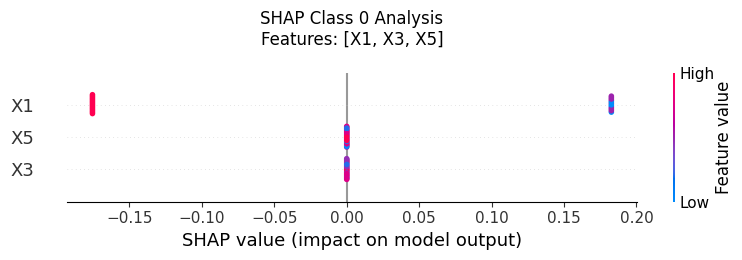

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


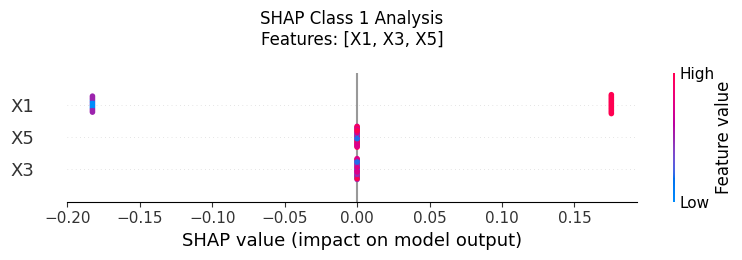

In [5]:
categorical_features = ["X1","X3","X5",]
parameter_grid = {
                    'max_depth':randint(1,3), 
                    'criterion':("gini", "entropy", "log_loss"),
                    'splitter': ("random", "best"),
                    'min_samples_split':randint(6,15),
                    'min_samples_leaf':randint(6,13),
                    'max_features': ("sqrt", "log2", None),
            }
search = t0.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100)
t0.feature_permutation(search.best_params_)
t0.shap_analysis(search.best_params_)

In [6]:
search.best_params_

{'criterion': 'log_loss',
 'max_depth': 1,
 'max_features': None,
 'min_samples_leaf': 9,
 'min_samples_split': 8,
 'splitter': 'best'}

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START criterion=gini, max_depth=3, max_features=log2, min_samples_leaf=9, min_samples_split=11, splitter=random
[CV 1/5; 1/100] END criterion=gini, max_depth=3, max_features=log2, min_samples_leaf=9, min_samples_split=11, splitter=random;, score=(train=0.550, test=0.550) total time=   0.0s
[CV 2/5; 1/100] START criterion=gini, max_depth=3, max_features=log2, min_samples_leaf=9, min_samples_split=11, splitter=random
[CV 2/5; 1/100] END criterion=gini, max_depth=3, max_features=log2, min_samples_leaf=9, min_samples_split=11, splitter=random;, score=(train=0.550, test=0.550) total time=   0.0s
[CV 3/5; 1/100] START criterion=gini, max_depth=3, max_features=log2, min_samples_leaf=9, min_samples_split=11, splitter=random
[CV 3/5; 1/100] END criterion=gini, max_depth=3, max_features=log2, min_samples_leaf=9, min_samples_split=11, splitter=random;, score=(train=0.550, test=0.550) total time=   0.0s
[CV 4/5; 1/100] 

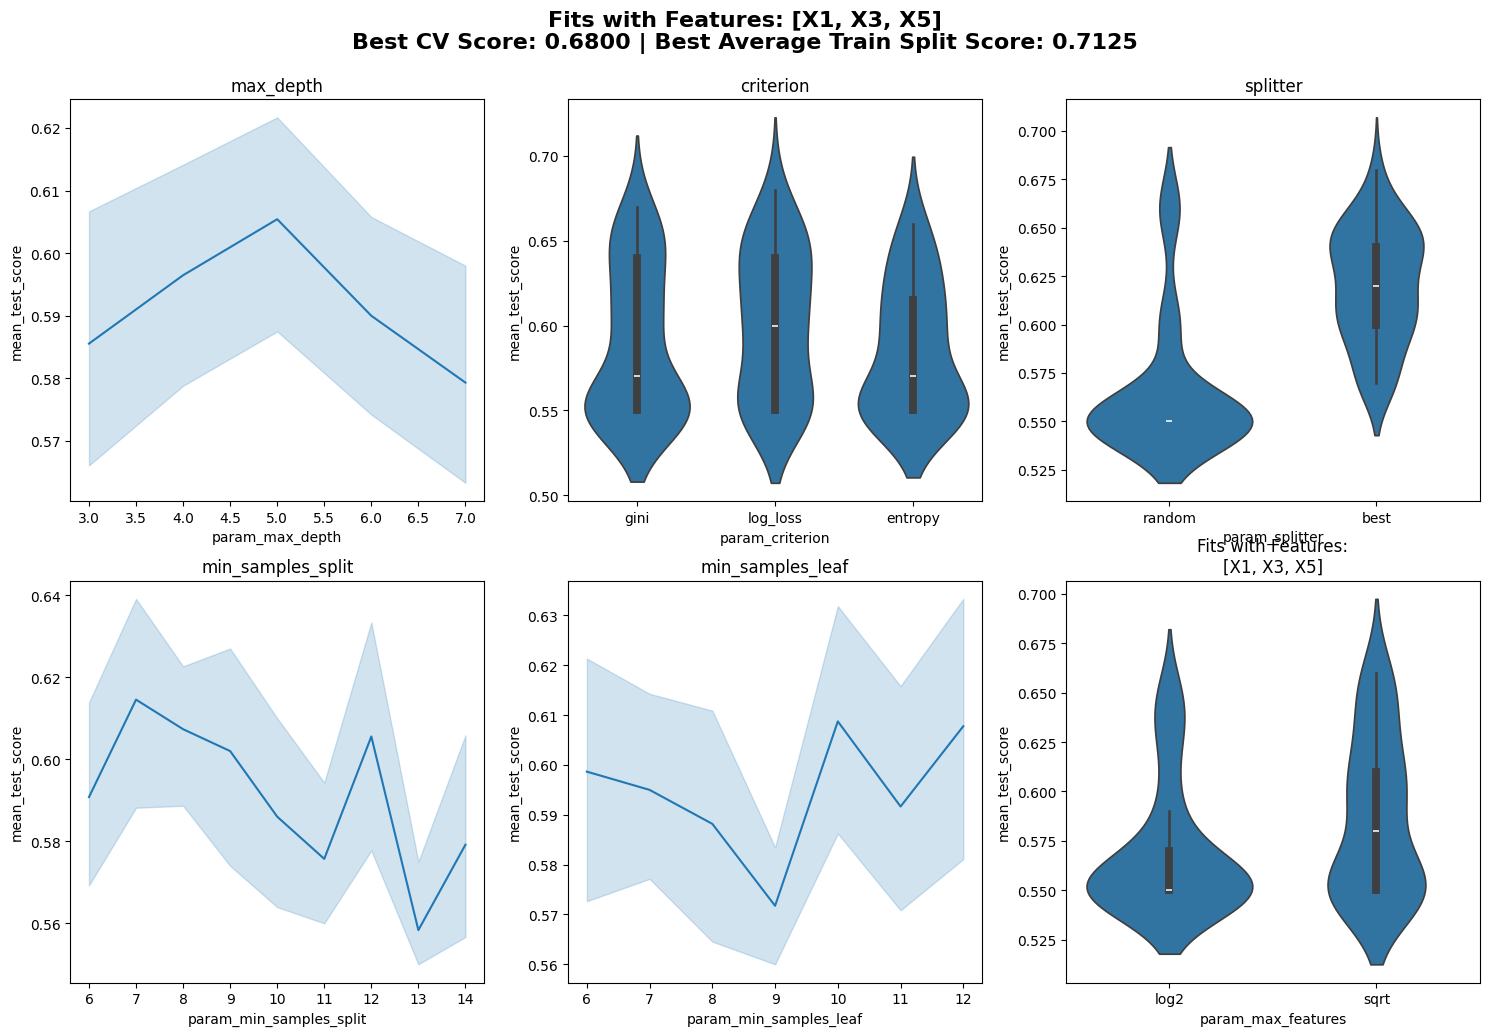



Feature Permutation Importance
______________________
X5: 0.115 +/- 0.077
X1: 0.058 +/- 0.071
X3: -0.023 +/- 0.058

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


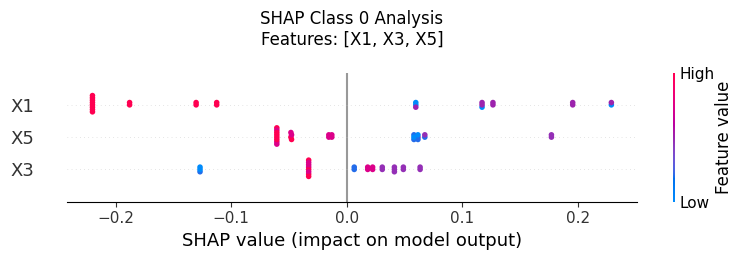

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


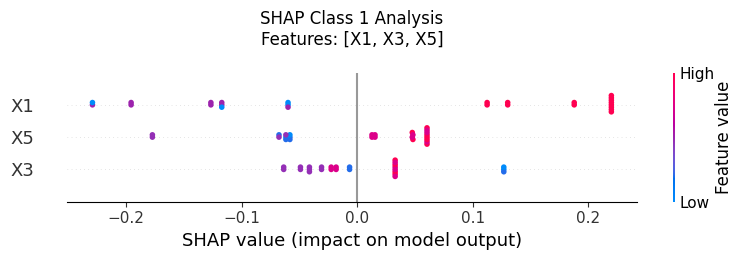

In [7]:
categorical_features = ["X1","X3","X5",]
parameter_grid = {
                    'max_depth':randint(3,8), 
                    'criterion':("gini", "entropy", "log_loss"),
                    'splitter': ("random", "best"),
                    'min_samples_split':randint(6,15),
                    'min_samples_leaf':randint(6,13),
                    'max_features': ("sqrt", "log2", None),
            }
search = t0.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100)
t0.feature_permutation(search.best_params_)
t0.shap_analysis(search.best_params_)

In [8]:
search.best_params_

{'criterion': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'min_samples_leaf': 6,
 'min_samples_split': 7,
 'splitter': 'best'}

test set prediction

In [9]:
t0.predict_test_split(search.best_params_)

0.5769230769230769

# Next iteration

fitting to a single variable may be more general than ensuring that there is more to each

In [10]:
random_state += 1

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START criterion=entropy, max_depth=4, max_features=sqrt, min_samples_leaf=9, min_samples_split=9, splitter=best
[CV 1/5; 1/100] END criterion=entropy, max_depth=4, max_features=sqrt, min_samples_leaf=9, min_samples_split=9, splitter=best;, score=(train=0.637, test=0.600) total time=   0.0s
[CV 2/5; 1/100] START criterion=entropy, max_depth=4, max_features=sqrt, min_samples_leaf=9, min_samples_split=9, splitter=best
[CV 2/5; 1/100] END criterion=entropy, max_depth=4, max_features=sqrt, min_samples_leaf=9, min_samples_split=9, splitter=best;, score=(train=0.662, test=0.500) total time=   0.0s
[CV 3/5; 1/100] START criterion=entropy, max_depth=4, max_features=sqrt, min_samples_leaf=9, min_samples_split=9, splitter=best
[CV 3/5; 1/100] END criterion=entropy, max_depth=4, max_features=sqrt, min_samples_leaf=9, min_samples_split=9, splitter=best;, score=(train=0.625, test=0.700) total time=   0.0s
[CV 4/5; 1/100] 

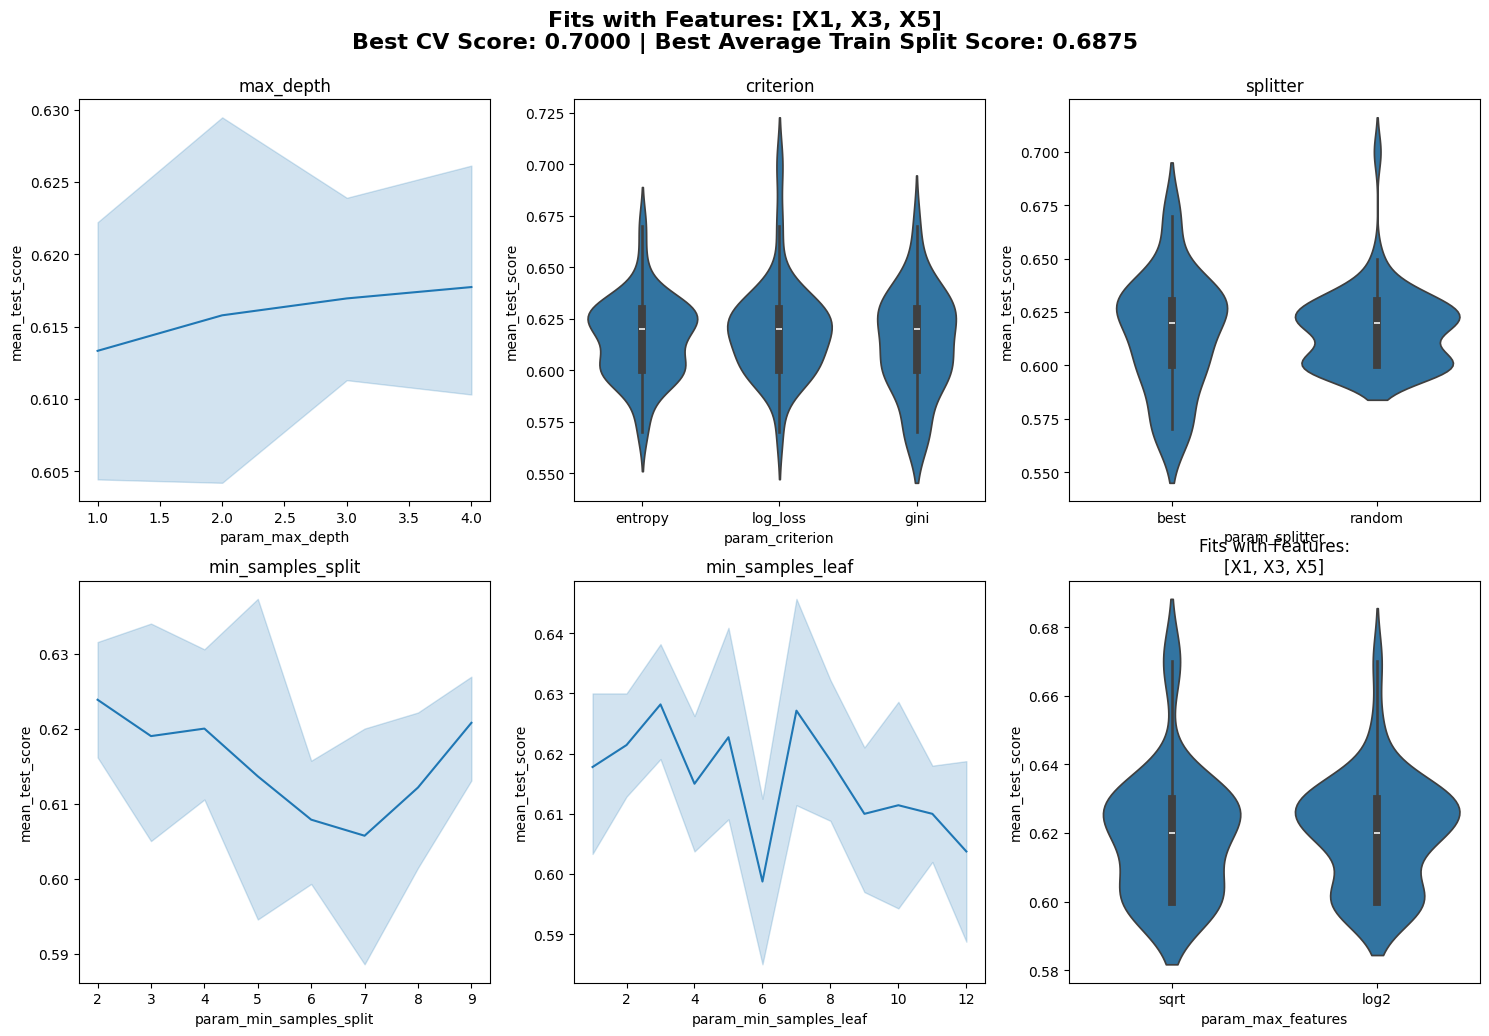



Feature Permutation Importance
______________________
X1: 0.223 +/- 0.084
X5: 0.042 +/- 0.058
X3: 0.000 +/- 0.000

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


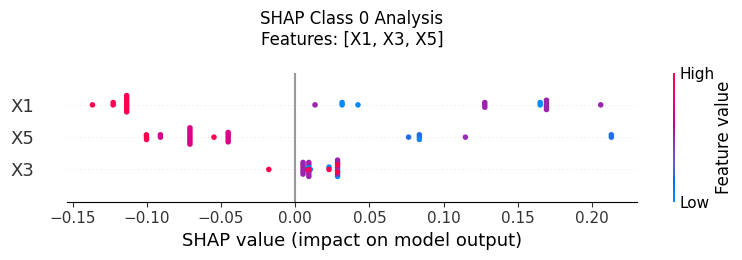

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


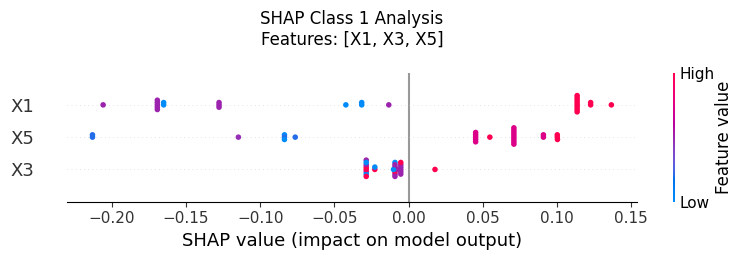

In [11]:
categorical_features = ["X1","X3","X5"]

model = ExtraTreeClassifier(random_state = random_state,)

t1 = ModelTuner(model, filename, "Y", categorical_features, random_state=random_state)

parameter_grid = {
                    'max_depth':randint(1,5), # trying to avoid overfitting
                    'criterion':("gini", "entropy", "log_loss"),
                    'splitter': ("random", "best"),
                    'min_samples_split':randint(2,10),
                    'min_samples_leaf':randint(1,13),
                    'max_features': ("sqrt", "log2", None),
            }
search = t1.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100)
t1.feature_permutation(search.best_params_)
t1.shap_analysis(search.best_params_)

In [12]:
search.best_params_

{'criterion': 'log_loss',
 'max_depth': 4,
 'max_features': None,
 'min_samples_leaf': 5,
 'min_samples_split': 5,
 'splitter': 'random'}

In [13]:
t1.predict_test_split(search.best_params_)

0.6923076923076923

maybe stricter regularization

In [14]:
random_state += 1

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START criterion=gini, max_depth=2, max_features=log2, min_samples_leaf=12, min_samples_split=7, splitter=random
[CV 1/5; 1/100] END criterion=gini, max_depth=2, max_features=log2, min_samples_leaf=12, min_samples_split=7, splitter=random;, score=(train=0.613, test=0.550) total time=   0.0s
[CV 2/5; 1/100] START criterion=gini, max_depth=2, max_features=log2, min_samples_leaf=12, min_samples_split=7, splitter=random
[CV 2/5; 1/100] END criterion=gini, max_depth=2, max_features=log2, min_samples_leaf=12, min_samples_split=7, splitter=random;, score=(train=0.550, test=0.550) total time=   0.0s
[CV 3/5; 1/100] START criterion=gini, max_depth=2, max_features=log2, min_samples_leaf=12, min_samples_split=7, splitter=random
[CV 3/5; 1/100] END criterion=gini, max_depth=2, max_features=log2, min_samples_leaf=12, min_samples_split=7, splitter=random;, score=(train=0.550, test=0.550) total time=   0.0s
[CV 4/5; 1/100] 

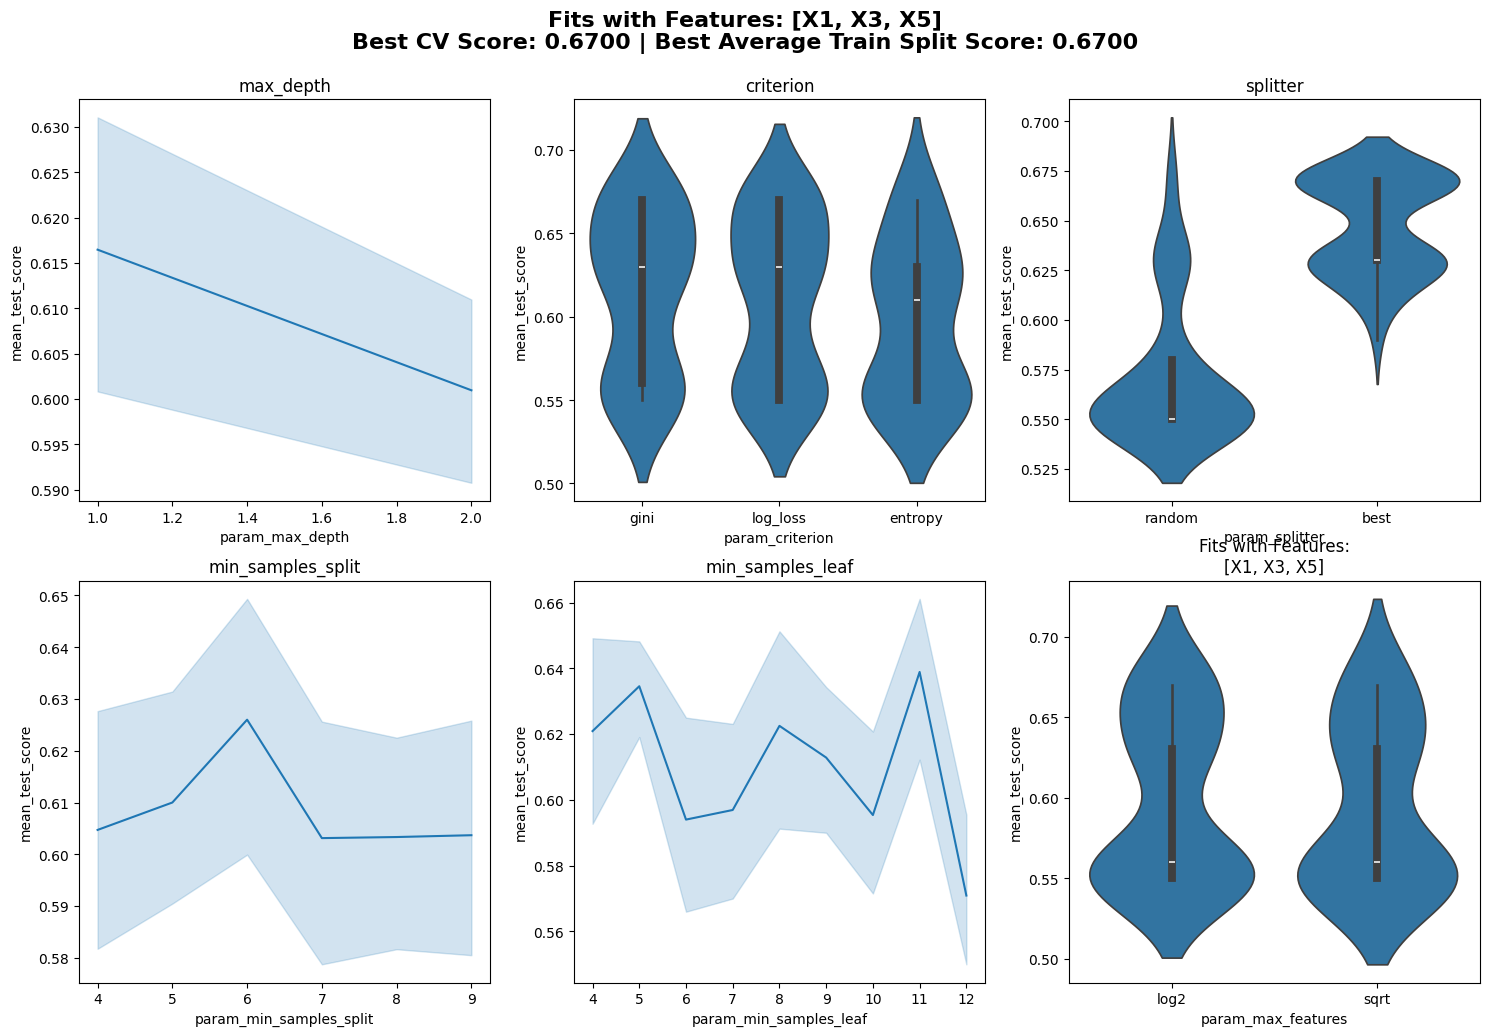



Feature Permutation Importance
______________________
X1: 0.085 +/- 0.156
X5: 0.000 +/- 0.000
X3: 0.000 +/- 0.000

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


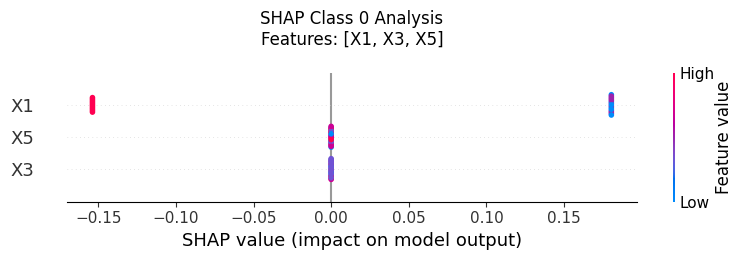

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


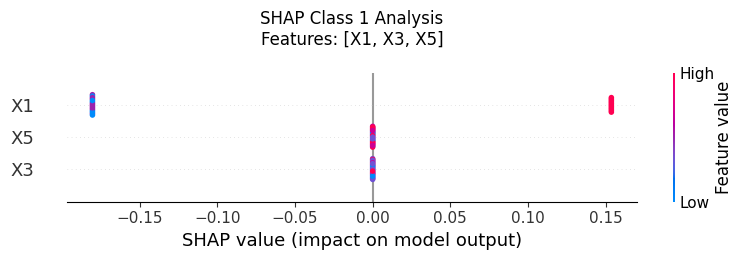

In [15]:
categorical_features = ["X1","X3","X5"]

model = ExtraTreeClassifier(random_state = random_state,)

t2 = ModelTuner(model, filename, "Y", categorical_features, random_state=random_state)

parameter_grid = {
                    'max_depth':randint(1,3), # trying to avoid overfitting
                    'criterion':("gini", "entropy", "log_loss"),
                    'splitter': ("random", "best"),
                    'min_samples_split':randint(4,10),
                    'min_samples_leaf':randint(4,13),
                    'max_features': ("sqrt", "log2", None),
            }
search = t2.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100)
t2.feature_permutation(search.best_params_)
t2.shap_analysis(search.best_params_)

In [16]:
search.best_params_

{'criterion': 'log_loss',
 'max_depth': 1,
 'max_features': 'sqrt',
 'min_samples_leaf': 8,
 'min_samples_split': 9,
 'splitter': 'best'}

In [17]:
t2.predict_test_split(search.best_params_)

0.5769230769230769

# checking other feature combinations

In [18]:
random_state += 1

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START criterion=log_loss, max_depth=1, max_features=log2, min_samples_leaf=7, min_samples_split=4, splitter=random
[CV 1/5; 1/100] END criterion=log_loss, max_depth=1, max_features=log2, min_samples_leaf=7, min_samples_split=4, splitter=random;, score=(train=0.588, test=0.600) total time=   0.0s
[CV 2/5; 1/100] START criterion=log_loss, max_depth=1, max_features=log2, min_samples_leaf=7, min_samples_split=4, splitter=random
[CV 2/5; 1/100] END criterion=log_loss, max_depth=1, max_features=log2, min_samples_leaf=7, min_samples_split=4, splitter=random;, score=(train=0.588, test=0.600) total time=   0.0s
[CV 3/5; 1/100] START criterion=log_loss, max_depth=1, max_features=log2, min_samples_leaf=7, min_samples_split=4, splitter=random
[CV 3/5; 1/100] END criterion=log_loss, max_depth=1, max_features=log2, min_samples_leaf=7, min_samples_split=4, splitter=random;, score=(train=0.575, test=0.650) total time=   0.0

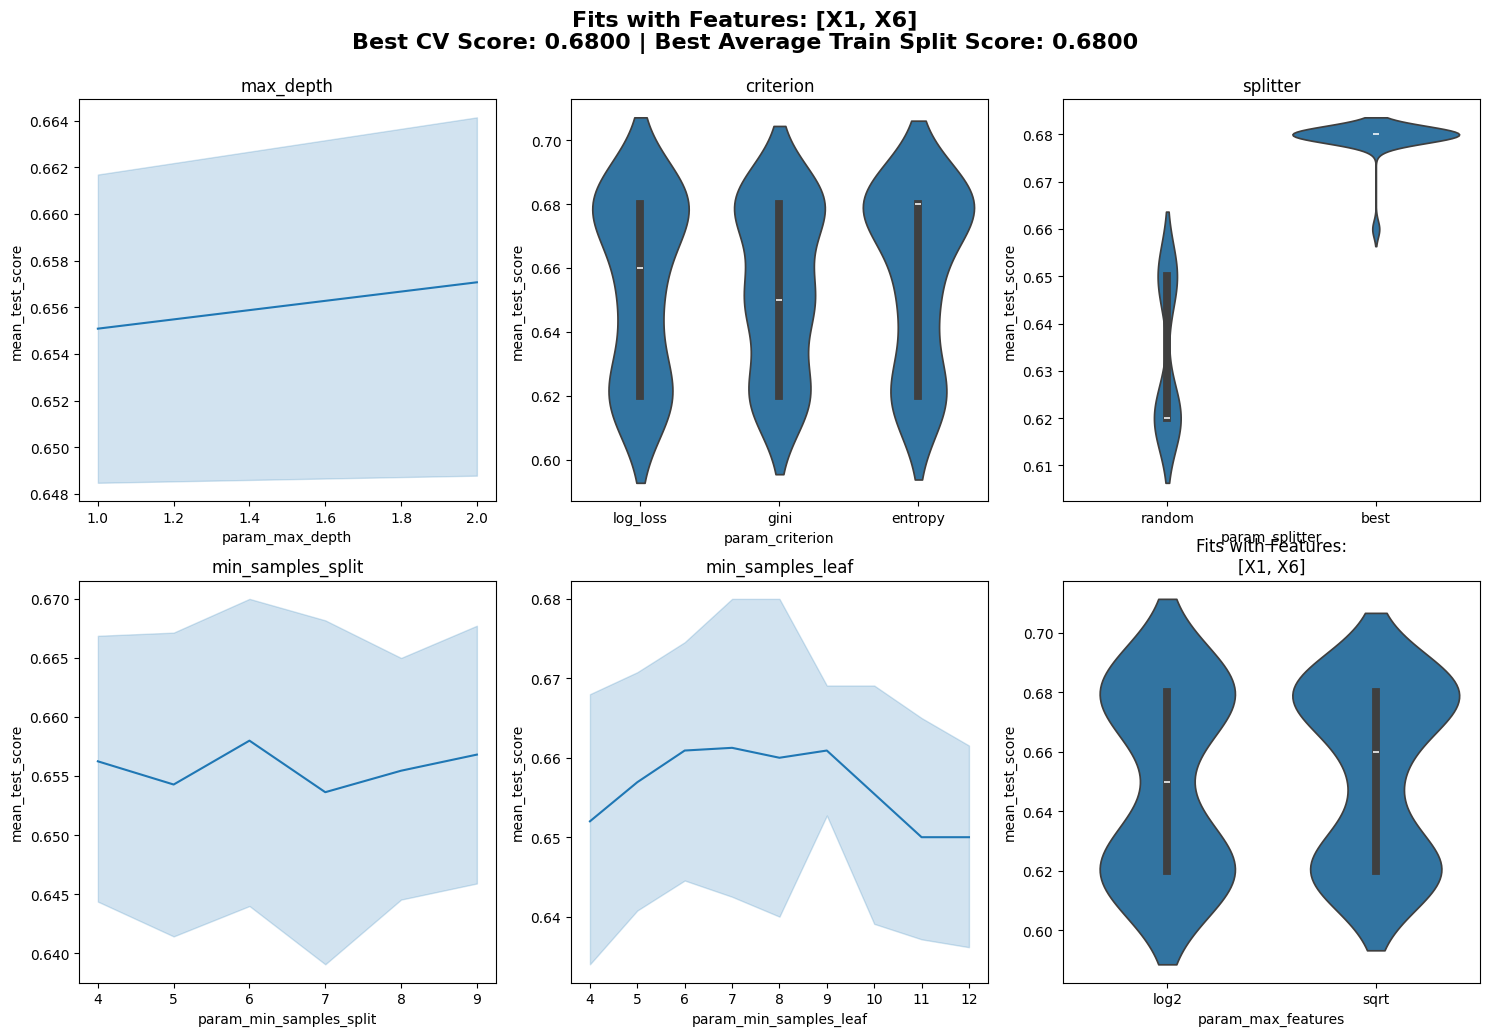



Feature Permutation Importance
______________________
X1: 0.115 +/- 0.093
X6: 0.000 +/- 0.000

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


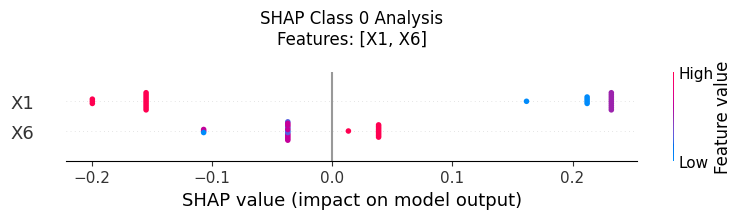

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


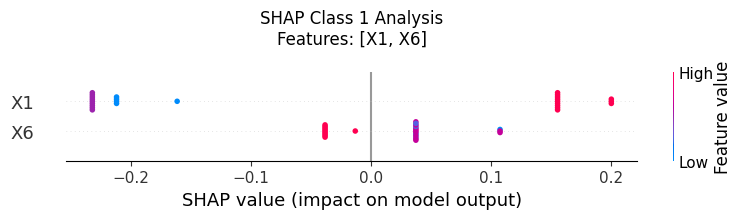

In [19]:
categorical_features = ["X1","X6"]

model = ExtraTreeClassifier(random_state = random_state,)

t3 = ModelTuner(model, filename, "Y", categorical_features, random_state=random_state)

parameter_grid = {
                    'max_depth':randint(1,3), # trying to avoid overfitting
                    'criterion':("gini", "entropy", "log_loss"),
                    'splitter': ("random", "best"),
                    'min_samples_split':randint(4,10),
                    'min_samples_leaf':randint(4,13),
                    'max_features': ("sqrt", "log2", None),
            }
search = t3.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100)
t3.feature_permutation(search.best_params_)
t3.shap_analysis(search.best_params_)

In [20]:
t3.predict_test_split(search.best_params_)

0.5384615384615384

In [21]:
random_state += 1

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START criterion=log_loss, max_depth=1, max_features=log2, min_samples_leaf=5, min_samples_split=4, splitter=best
[CV 1/5; 1/100] END criterion=log_loss, max_depth=1, max_features=log2, min_samples_leaf=5, min_samples_split=4, splitter=best;, score=(train=0.575, test=0.800) total time=   0.0s
[CV 2/5; 1/100] START criterion=log_loss, max_depth=1, max_features=log2, min_samples_leaf=5, min_samples_split=4, splitter=best
[CV 2/5; 1/100] END criterion=log_loss, max_depth=1, max_features=log2, min_samples_leaf=5, min_samples_split=4, splitter=best;, score=(train=0.613, test=0.650) total time=   0.0s
[CV 3/5; 1/100] START criterion=log_loss, max_depth=1, max_features=log2, min_samples_leaf=5, min_samples_split=4, splitter=best
[CV 3/5; 1/100] END criterion=log_loss, max_depth=1, max_features=log2, min_samples_leaf=5, min_samples_split=4, splitter=best;, score=(train=0.637, test=0.550) total time=   0.0s
[CV 4/5; 1

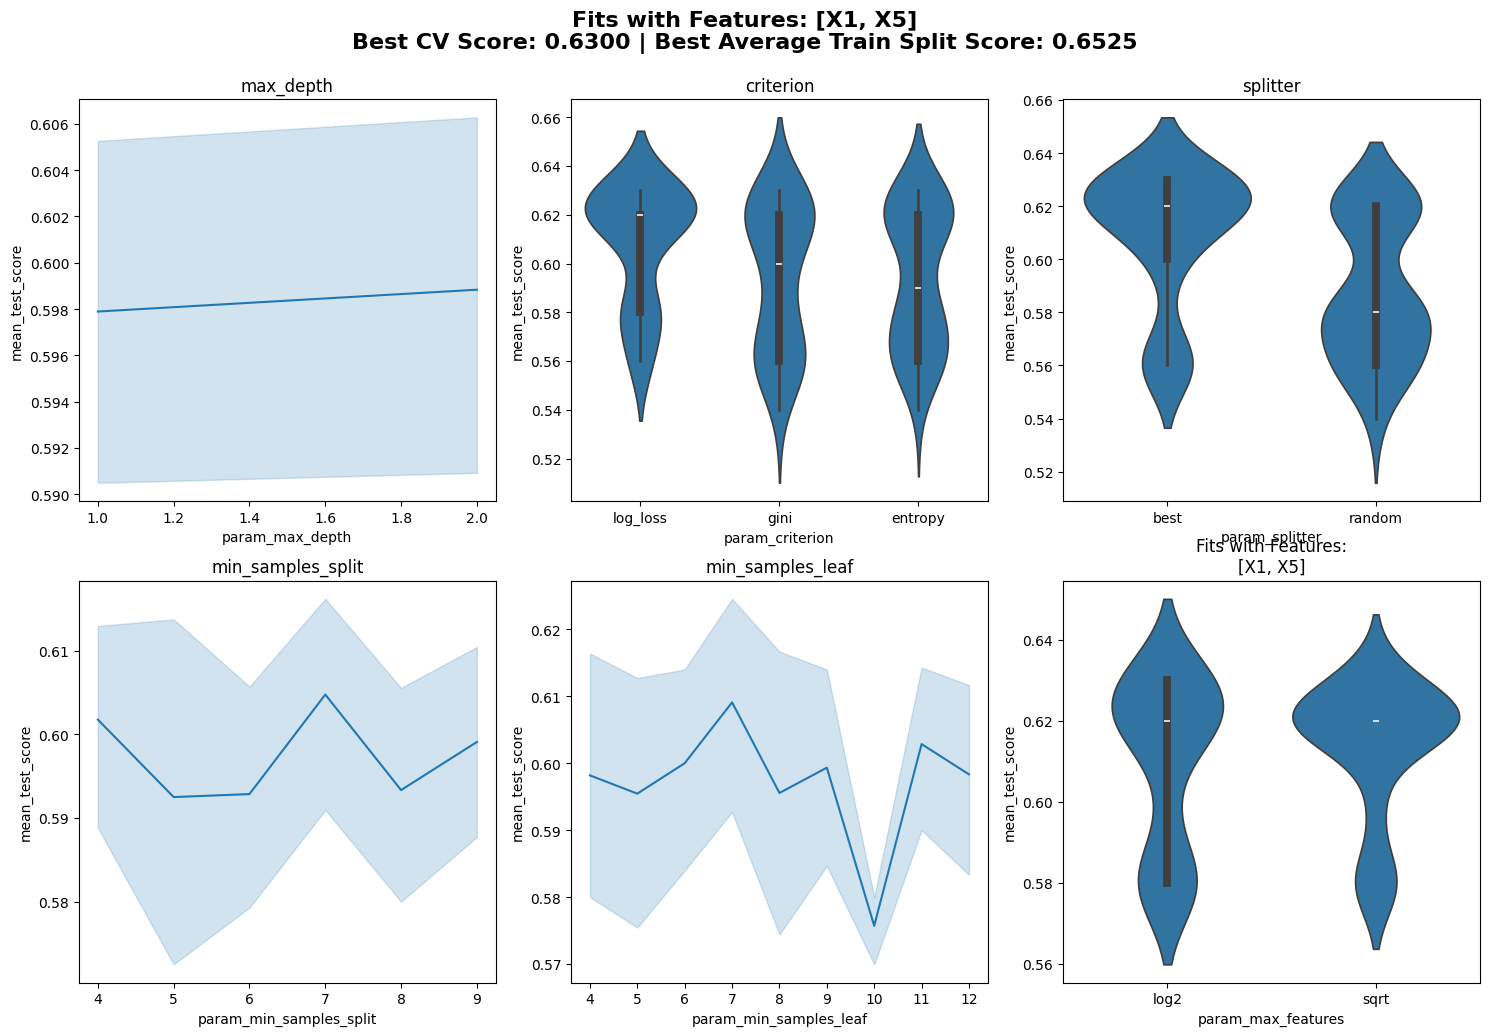



Feature Permutation Importance
______________________
X1: 0.235 +/- 0.044
X5: 0.062 +/- 0.026

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


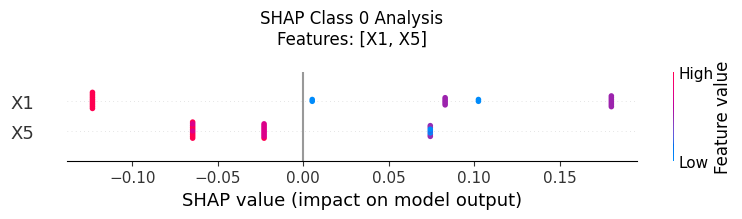

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:292: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset, show=False)


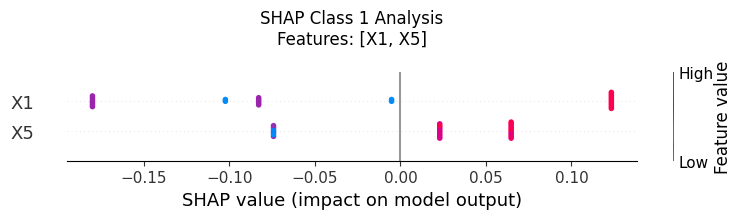

In [22]:
categorical_features = ["X1","X5"]

model = ExtraTreeClassifier(random_state = random_state,)

t4 = ModelTuner(model, filename, "Y", categorical_features, random_state=random_state)

parameter_grid = {
                    'max_depth':randint(1,3), # trying to avoid overfitting
                    'criterion':("gini", "entropy", "log_loss"),
                    'splitter': ("random", "best"),
                    'min_samples_split':randint(4,10),
                    'min_samples_leaf':randint(4,13),
                    'max_features': ("sqrt", "log2", None),
            }
search = t4.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100)
t4.feature_permutation(search.best_params_)
t4.shap_analysis(search.best_params_)

In [23]:
search.best_params_

{'criterion': 'entropy',
 'max_depth': 2,
 'max_features': 'sqrt',
 'min_samples_leaf': 7,
 'min_samples_split': 6,
 'splitter': 'best'}

In [24]:
t4.predict_test_split(search.best_params_)

0.7692307692307693

# Saving the best ExtraTree model

In [25]:
print(t1.last_search.best_score_)
print(t1.saved_score)

0.7
0.6923076923076923


In [26]:
import pandas as pd
pd.DataFrame(t1.last_search.cv_results_).loc[t1.last_search.best_index_]


mean_fit_time                                                       0.002011
std_fit_time                                                        0.000495
mean_score_time                                                     0.001485
std_score_time                                                      0.000139
param_criterion                                                     log_loss
param_max_depth                                                            4
param_max_features                                                       NaN
param_min_samples_leaf                                                     5
param_min_samples_split                                                    5
param_splitter                                                        random
params                     {'criterion': 'log_loss', 'max_depth': 4, 'max...
split0_test_score                                                       0.75
split1_test_score                                                        0.7

In [27]:
t1.get_features()

['X1', 'X3', 'X5']

In [28]:
t1.save_model(r"../../src/models/saved_models/ExtraTreeClassifier", t1.last_search.best_params_, True, notes= "CV score = 0.7; test score = 0.6923076923076923")